# layer Normilization

in this note book there is a demenstoration of now to apply layer normalization 

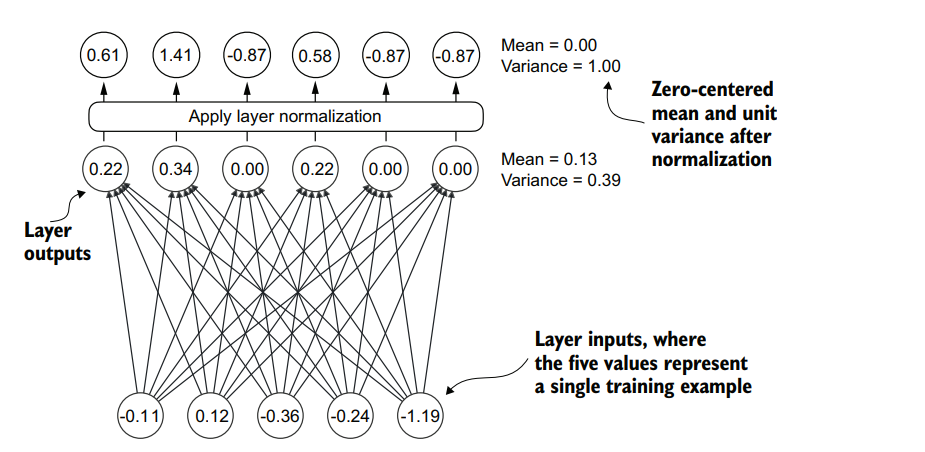

In [7]:
import torch
import torch.nn as nn

In [8]:
torch.manual_seed(20)
batch_example = torch.randn(2,5)
layer = nn.Sequential(nn.Linear(5,6),nn.ReLU())
out = layer(batch_example)

print(out)

tensor([[0.2767, 0.2562, 1.0237, 0.5401, 0.0000, 1.6634],
        [0.0000, 0.0000, 0.7431, 0.7690, 0.1188, 0.0000]],
       grad_fn=<ReluBackward0>)


Before we apply layer normalization to these outputs, let’s examine the mean and
variance

In [9]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.6267],
        [0.2718]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.3785],
        [0.1429]], grad_fn=<VarBackward0>)


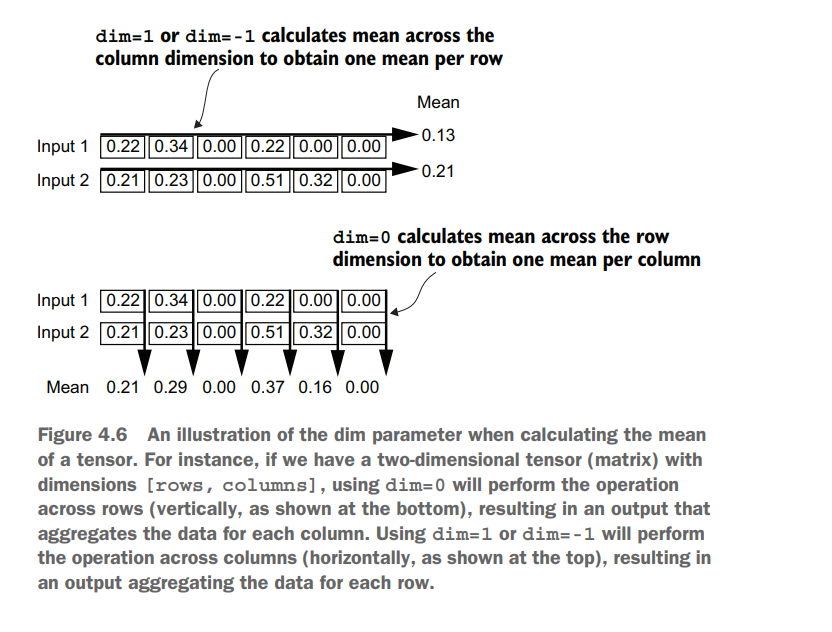

Next, let’s apply layer normalization to the layer outputs we obtained earlier. The
operation consists of subtracting the mean and dividing by the square root of the variance (also known as the standard deviation)

In [10]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[-0.5688, -0.6023,  0.6453, -0.1407, -1.0187,  1.6851],
        [-0.7191, -0.7191,  1.2467,  1.3154, -0.4049, -0.7191]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-2.7319e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


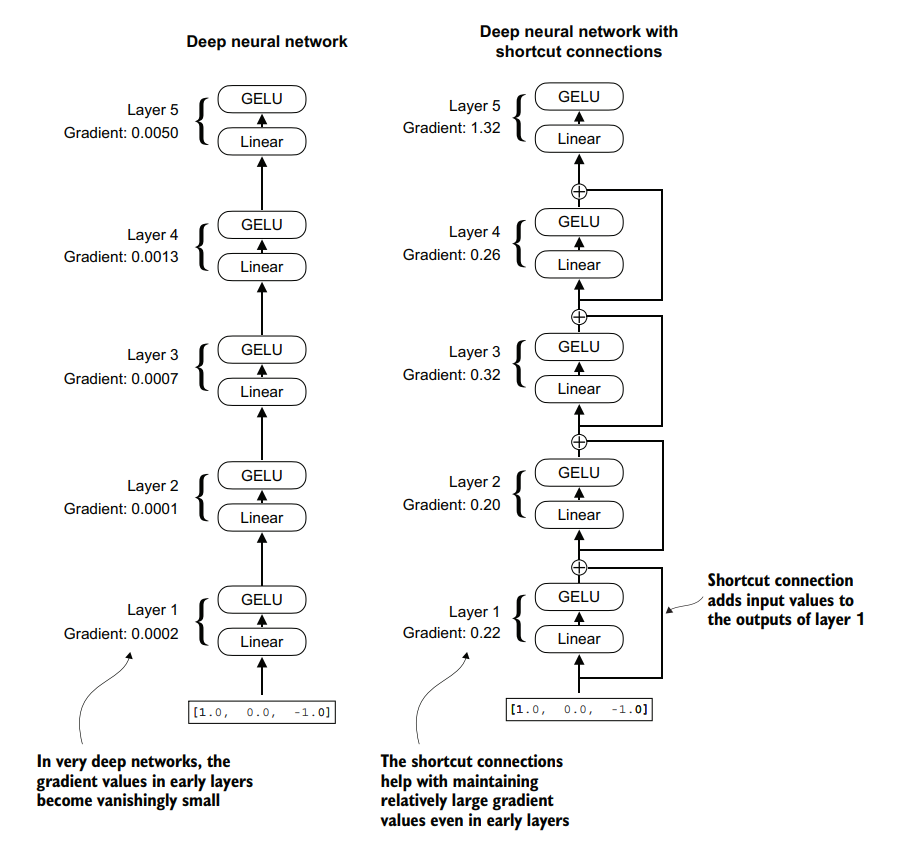

In [11]:
import torch
import torch.nn as nn

class GELU(nn.Module):
    def forward(self, x):
        return torch.nn.functional.gelu(x)

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, shortcut_indices=None):
        super().__init__()
        # shortcut_indices can be a list like [1, 3] specifying which layers get a residual connection
        self.shortcut_indices = shortcut_indices if shortcut_indices is not None else []
        
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            layer_output = layer(x)
            
            # Apply shortcut only if the current index is designated AND shapes match
            if i in self.shortcut_indices and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
                
        return x

# Example usage: apply shortcuts only on layer index 1 and layer index 3
layer_sizes = [784, 256, 256, 256, 256, 10]
model = ExampleDeepNeuralNetwork(layer_sizes, shortcut_indices=[1, 3])